## Energy Prediction - Exploratory Data Analysis (EDA)

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv('../data/raw/energy_data_set.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.60,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.48,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.37,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.25,733.8,92.0,6.000000,51.500000,5.0,45.410390,45.410390
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.13,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [12]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         19735 non-null  datetime64[ns]
 1   Appliances   19735 non-null  int64         
 2   lights       19735 non-null  int64         
 3   T1           19735 non-null  float64       
 4   RH_1         19735 non-null  float64       
 5   T2           19735 non-null  float64       
 6   RH_2         19735 non-null  float64       
 7   T3           19735 non-null  float64       
 8   RH_3         19735 non-null  float64       
 9   T4           19735 non-null  float64       
 10  RH_4         19735 non-null  float64       
 11  T5           19735 non-null  float64       
 12  RH_5         19735 non-null  float64       
 13  T6           19735 non-null  float64       
 14  RH_6         19735 non-null  float64       
 15  T7           19735 non-null  float64       
 16  RH_7

In [13]:
print(df.describe())

                      date    Appliances        lights            T1  \
count                19735  19735.000000  19735.000000  19735.000000   
mean   2016-03-20 05:30:00     97.694958      3.801875     21.686571   
min    2016-01-11 17:00:00     10.000000      0.000000     16.790000   
25%    2016-02-14 23:15:00     50.000000      0.000000     20.760000   
50%    2016-03-20 05:30:00     60.000000      0.000000     21.600000   
75%    2016-04-23 11:45:00    100.000000      0.000000     22.600000   
max    2016-05-27 18:00:00   1080.000000     70.000000     26.260000   
std                    NaN    102.524891      7.935988      1.606066   

               RH_1            T2          RH_2            T3          RH_3  \
count  19735.000000  19735.000000  19735.000000  19735.000000  19735.000000   
mean      40.259739     20.341219     40.420420     22.267611     39.242500   
min       27.023333     16.100000     20.463333     17.200000     28.766667   
25%       37.333333     18.790000  

**Time-Series Visualization**

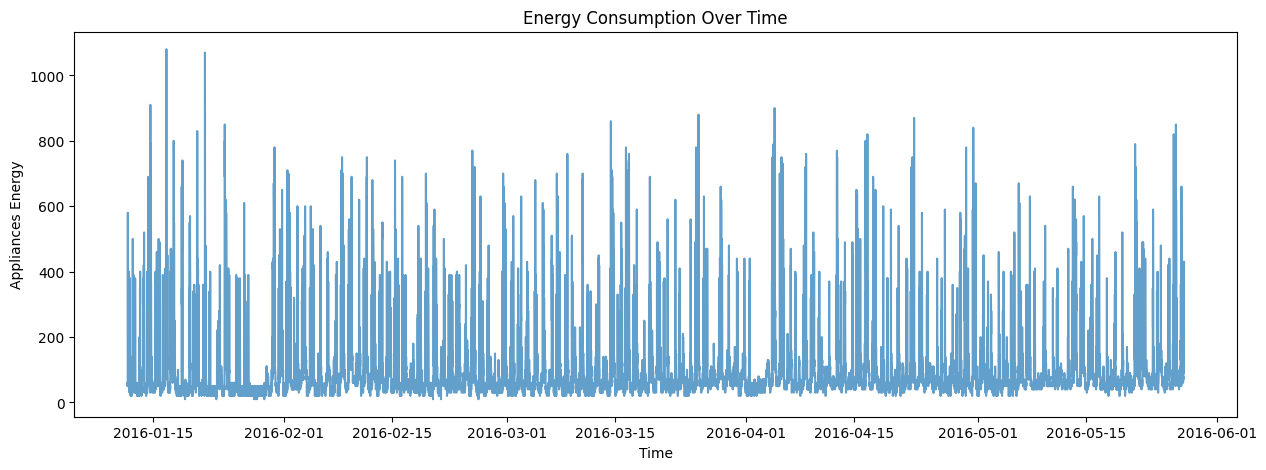

In [14]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['Appliances'], alpha=0.7)
plt.title("Energy Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Appliances Energy")
plt.show()

The energy consumption shows high variability with frequent spikes. This indicates irregular usage patterns and the need for models that capture temporal dependencies.

**Hourly Pattern**

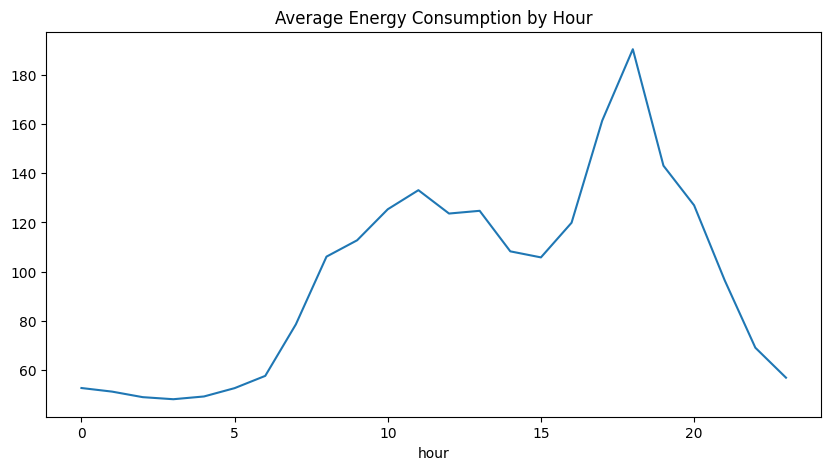

In [15]:
df['hour'] = df['date'].dt.hour

hourly_avg = df.groupby('hour')['Appliances'].mean()

plt.figure(figsize=(10,5))
hourly_avg.plot()
plt.title("Average Energy Consumption by Hour")
plt.show()

Energy consumption peaks during evening hours, justifying the creation of the "is_peak_hour" feature.

**Day wise Pattern**

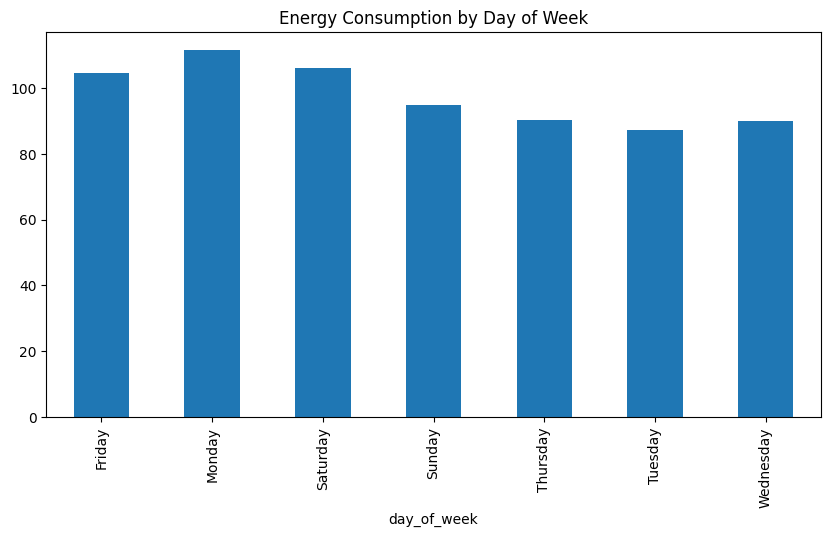

In [16]:
df['day_of_week'] = df['date'].dt.day_name()

daily_avg = df.groupby('day_of_week')['Appliances'].mean()

daily_avg.plot(kind='bar', figsize=(10,5))
plt.title("Energy Consumption by Day of Week")
plt.show()

Slight variation across days suggests behavioral differences, supporting the use of weekday/weekend features.

**Correlation Analysis**

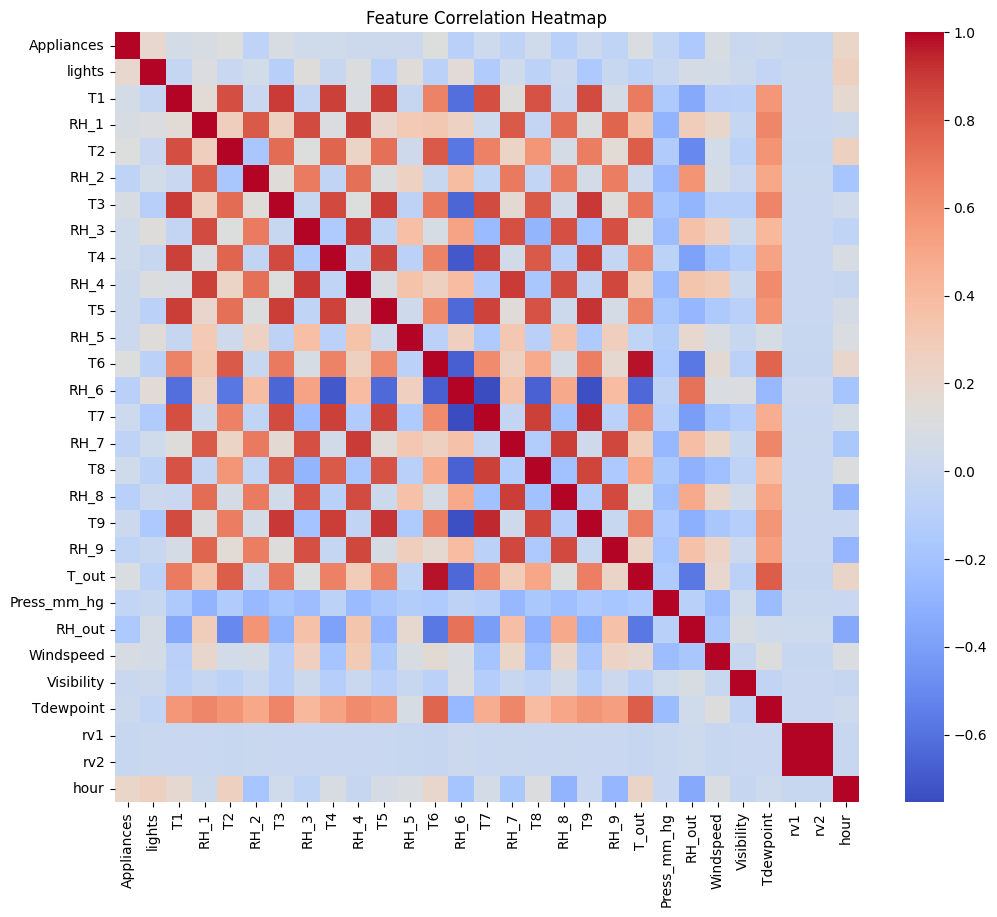

In [18]:
plt.figure(figsize=(12,10))
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

Temperature and humidity features show strong correlation, indicating redundancy but also useful interaction effects.

**Distribution Analysis**

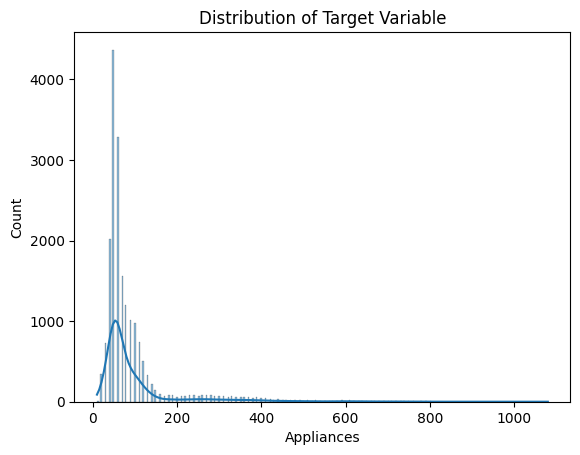

In [19]:
sns.histplot(df['Appliances'], kde=True)
plt.title("Distribution of Target Variable")
plt.show()

The target variable is right-skewed, with most values low and few extreme spikes.

**Outlier Visualization**

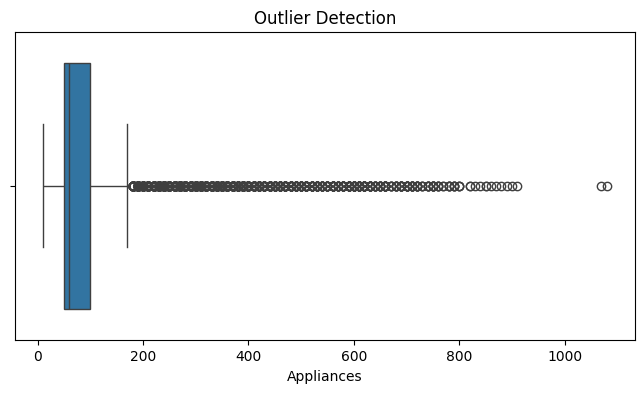

In [20]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Appliances'])
plt.title("Outlier Detection")
plt.show()

Significant outliers are present, which may impact model performance and require handling.

**Rolling Mean**

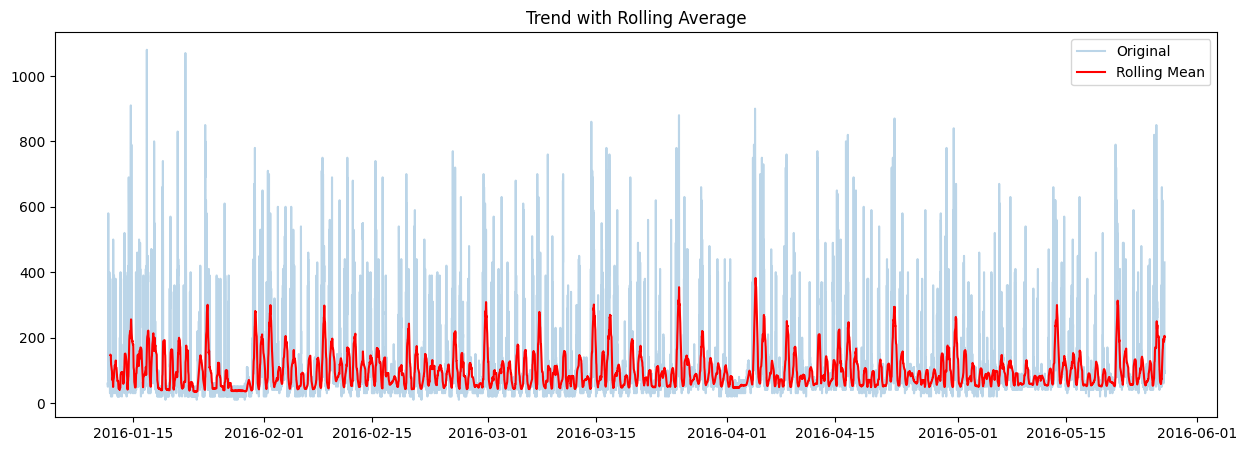

In [21]:
df['rolling_mean'] = df['Appliances'].rolling(window=50).mean()

plt.figure(figsize=(15,5))
plt.plot(df['date'], df['Appliances'], alpha=0.3, label='Original')
plt.plot(df['date'], df['rolling_mean'], color='red', label='Rolling Mean')
plt.legend()
plt.title("Trend with Rolling Average")
plt.show()

**Auto Correlation**

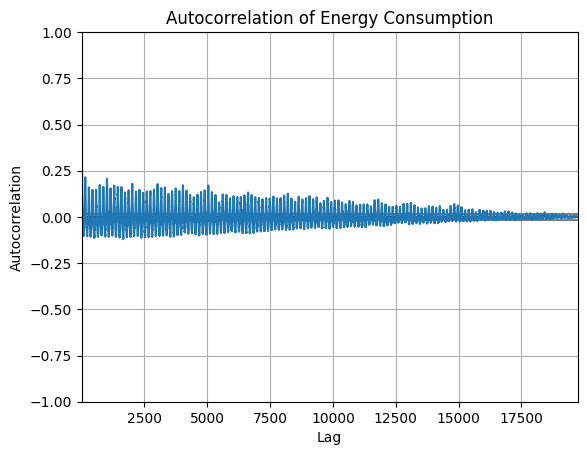

In [22]:
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(df['Appliances'])
plt.title("Autocorrelation of Energy Consumption")
plt.show()

Strong autocorrelation at short lags confirms temporal dependency, supporting the use of lag features and LSTM models.